In [13]:
import requests
import pandas as pd
import numpy as np
import time
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
def fetch_noaa_kp_index():
    url = "https://services.swpc.noaa.gov/products/noaa-planetary-k-index.json"
    max_retries = 3

    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=10)
            response.raise_for_status()
            data = response.json()

            columns = data[0]
            rows = data[1:]

            df = pd.DataFrame(rows, columns=columns)
            df['time_tag'] = pd.to_datetime(df['time_tag'])
            df['Kp'] = df['Kp'].astype(float)

            df = df[['time_tag', 'Kp']]
            df.sort_values('time_tag', inplace=True)
            df.reset_index(drop=True, inplace=True)

            print(f"noaa api success. total records: {len(df)}")
            return df

        except requests.exceptions.RequestException as e:
            print(f"noaa api mistake. total records: {attempt+1}/{max_retries}): {e}")
            time.sleep(2)

    print("no take the data")
    return None

In [7]:
df_kp = fetch_noaa_kp_index()

noaa api success. total records: 58


In [9]:
def generate_texbat_proxy_log(start_time, duration_seconds=3600, spoofing_start=1800):
    try:
        time_index = [start_time + timedelta(seconds=i) for i in range(duration_seconds)]

        cn0 = np.random.normal(45, 1.5, duration_seconds)
        doppler = 1500 * np.sin(np.linspace(0, 2*np.pi, duration_seconds)) + np.random.normal(0, 5, duration_seconds)

        drag_off_duration = 120
        spoofing_end = spoofing_start + drag_off_duration

        cn0[spoofing_start:spoofing_end] -= np.linspace(0, 15, drag_off_duration)
        cn0[spoofing_end:] -= 15 + np.random.normal(0, 2, duration_seconds - spoofing_end)
        doppler[spoofing_start:] += np.linspace(0, 500, duration_seconds - spoofing_start)

        df = pd.DataFrame({
            'time_tag': time_index,
            'C_N0': cn0,
            'doppler_hz': doppler,
            'is_spoofed': [0]*spoofing_start + [1]*(duration_seconds - spoofing_start)
        })

        print(f"texbat proxy success. total records: {len(df)}")
        return df

    except Exception as e:
        print(f"texbat proxy mistake. detail: {e}")
        print("no take the data")
        return None

start_time_sync = df_kp['time_tag'].iloc[0]

df_gnss = generate_texbat_proxy_log(start_time=start_time_sync)

texbat proxy success. total records: 3600


In [10]:
def merge_and_prepare_features(df_high_freq, df_low_freq):
    try:
        df_high_freq = df_high_freq.sort_values('time_tag')
        df_low_freq = df_low_freq.sort_values('time_tag')

        df_merged = pd.merge_asof(
            df_high_freq,
            df_low_freq,
            on='time_tag',
            direction='backward'
        )

        print(f"merge success. total records: {len(df_merged)}")
        return df_merged

    except Exception as e:
        print(f"merge mistake. detail: {e}")
        print("no take the data")
        return None
df_final = merge_and_prepare_features(df_gnss, df_kp)

merge success. total records: 3600


In [14]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

In [39]:
  def plot_time_scale_conflict(df):
        fig, ax1 = plt.subplots(figsize=(12, 5))

        color_gnss = '#c0392b'
        ax1.set_xlabel('Time (UTC)')
        ax1.set_ylabel('GNSS C/N0 (dB-Hz) [1 Hz Sample Rate]', color=color_gnss, fontweight='bold')
        ax1.plot(df['time_tag'], df['C_N0'], color=color_gnss, alpha=0.7, label='GNSS Signal (C/N0)')
        ax1.tick_params(axis='y', labelcolor=color_gnss)

        ax2 = ax1.twinx()
        color_sw = '#2980b9'
        ax2.set_ylabel('Space Weather Kp Index [3-Hour Resolution]', color=color_sw, fontweight='bold')
        ax2.plot(df['time_tag'], df['Kp'], color=color_sw, linewidth=4, linestyle='--', label='Macro Kp Index')
        ax2.tick_params(axis='y', labelcolor=color_sw)

        spoof_start = df[df['is_spoofed'] == 1]['time_tag'].min()
        plt.axvline(x=spoof_start, color='black', linestyle=':', linewidth=2)
        plt.text(spoof_start, ax2.get_ylim()[1]*0.9, '  Attack Start (Sub-second Latency Required)', color='black', fontweight='bold')

        plt.title('PROOF 1: Decision Latency Paradox (GNSS Dynamics vs. Macro Indices)', fontweight='bold')
        fig.tight_layout()
        plt.show()

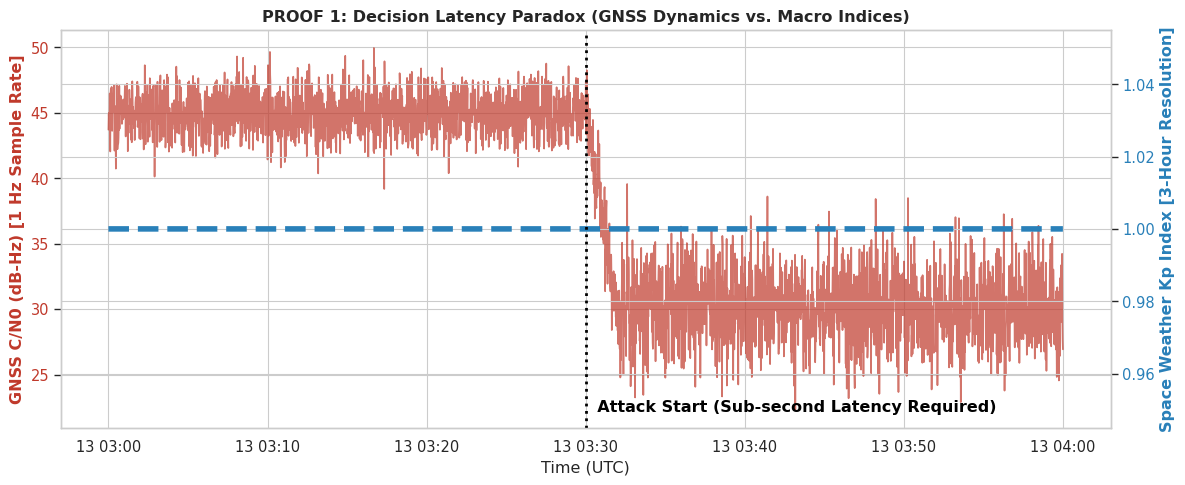

In [23]:
plot_time_scale_conflict(df_final)

In [24]:
  def plot_kmeans_weakness(df):
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x='C_N0', y='doppler_hz', hue='is_spoofed', palette=['#34495e', '#e74c3c'], alpha=0.6, s=50)

        plt.title('PROOF 2: Euclidean Distance Failure in Feature Space (K-Means Limitation)', fontweight='bold')
        plt.xlabel('C/N0 (dB-Hz)')
        plt.ylabel('Doppler Shift (Hz)')

        # Legend labels
        handles, labels = plt.gca().get_legend_handles_labels()
        plt.legend(handles, ['Nominal (Clean)', 'Electronic Interference (Spoofing)'], title='Signal Status')
        plt.show()

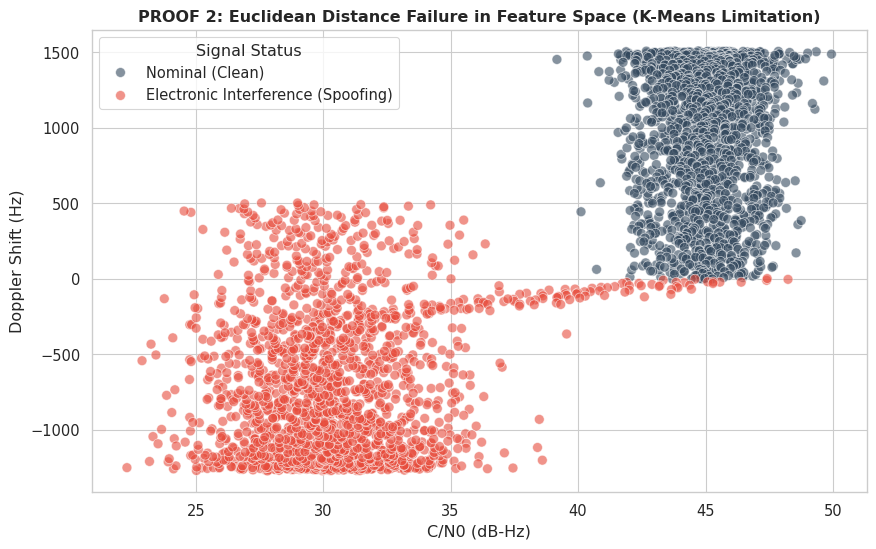

In [25]:
plot_kmeans_weakness(df_final)

In [28]:
  def plot_correlation_heatmap(df):
        plt.figure(figsize=(8, 6))
        corr_cols = ['C_N0', 'doppler_hz', 'Kp', 'is_spoofed']
        display_df = df[corr_cols].rename(columns={
            'C_N0': 'Signal_CN0',
            'doppler_hz': 'Doppler_Shift',
            'Kp': 'SpaceWeather_Kp',
            'is_spoofed': 'Target_Label'
        })

        corr_matrix = display_df.corr(method='spearman')

        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)

        plt.title('PROOF 3: Spearman Correlation Analysis (Feature Orthogonality)', fontweight='bold')
        plt.show()

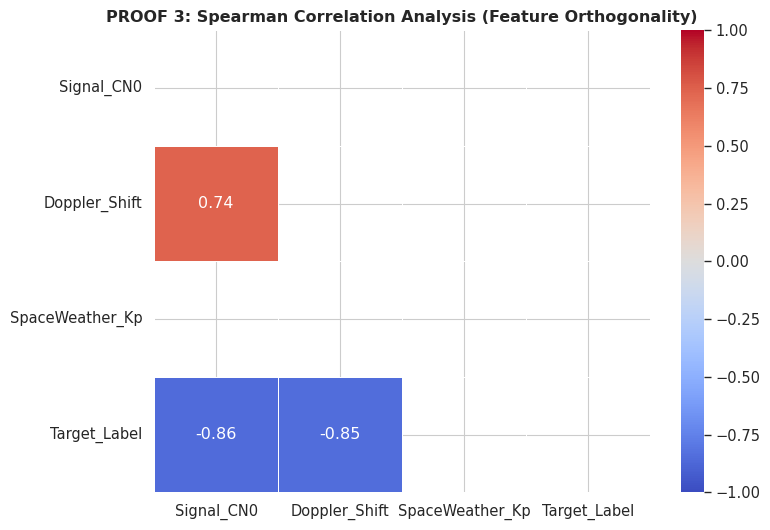

In [29]:
plot_correlation_heatmap(df_final)

In [30]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [33]:
    def apply_feature_engineering(df):
        df_eng = df.copy()
        df_eng['CN0_std_5s'] = df_eng['C_N0'].rolling(window=5).std()
        df_eng['CN0_mean_5s'] = df_eng['C_N0'].rolling(window=5).mean()
        df_eng['Doppler_diff'] = df_eng['doppler_hz'].diff()
        df_eng['Kp_delta'] = df_eng['Kp'].diff()
        df_eng = df_eng.dropna()

        print(f"feature engineering success. total features: {len(df_eng.columns)}")
        return df_eng

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
    def prepare_train_test_sets(df):
        features = ['C_N0', 'doppler_hz', 'Kp', 'CN0_std_5s', 'CN0_mean_5s', 'Doppler_diff', 'Kp_delta']
        X = df[features]
        y = df['is_spoofed']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

        print(f"split success. train size: {len(X_train)}, test size: {len(X_test)}")
        return X_train, X_test, y_train, y_test, features

In [46]:
df_ml_ready = apply_feature_engineering(df_final)

feature engineering success. total features: 9


In [47]:
df_ml_ready

,time_tag,C_N0,doppler_hz,is_spoofed,Kp,CN0_std_5s,CN0_mean_5s,Doppler_diff,Kp_delta
4,2026-04-13 03:00:04,44.615141,15.124202,0,1.0,0.509046,44.541958,13.770974,0.0
5,2026-04-13 03:00:05,46.460450,9.830351,0,1.0,0.787667,45.094230,-5.293850,0.0
6,2026-04-13 03:00:06,43.243014,12.018110,0,1.0,1.153982,44.766713,2.187758,0.0
7,2026-04-13 03:00:07,42.035351,12.766005,0,1.0,1.694968,44.269859,0.747895,0.0
8,2026-04-13 03:00:08,46.493361,20.888903,0,1.0,1.965992,44.569464,8.122899,0.0
...,...,...,...,...,...,...,...,...,...
3595,2026-04-13 03:59:55,31.476710,491.485217,1,1.0,1.816960,31.174182,1.411303,0.0
3596,2026-04-13 03:59:56,34.216440,489.795701,1,1.0,2.254603,31.541556,-1.689516,0.0
3597,2026-04-13 03:59:57,28.996261,502.356322,1,1.0,2.223809,30.671979,12.560621,0.0
3598,2026-04-13 03:59:58,27.580305,502.592280,1,1.0,2.560178,30.382431,0.235958,0.0


In [38]:
    def train_xgboost_regressor(X_train, y_train):
        model = xgb.XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            objective='reg:squarederror',
            random_state=42
        )
        model.fit(X_train, y_train)

        print("xgboost train success.")
        return model

In [48]:
X_train, X_test, y_train, y_test, f_names = prepare_train_test_sets(df_ml_ready)

split success. train size: 2876, test size: 720


In [49]:
model = train_xgboost_regressor(X_train, y_train)

xgboost train success.


In [40]:
    def evaluate_and_show_importance(model, X_test, y_test, feature_names):
        y_pred = model.predict(X_test)

        metrics = {
            "MAE": mean_absolute_error(y_test, y_pred),
            "MSE": mean_squared_error(y_test, y_pred),
            "R2": r2_score(y_test, y_pred)
        }
        for name, val in metrics.items():
            print(f"{name}: {val:.4f}")
        imp_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False)

        print("\n importance rank:")
        print(imp_df)

In [50]:
evaluate_and_show_importance(model, X_test, y_test, f_names)

MAE: 0.2422
MSE: 0.2416
R2: 0.0000

 importance rank:
        Feature  Importance
1    doppler_hz    0.991482
5  Doppler_diff    0.003739
3    CN0_std_5s    0.001966
4   CN0_mean_5s    0.001945
0          C_N0    0.000868
2            Kp    0.000000
6      Kp_delta    0.000000
